In [2]:
import h5py
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
import os
from collections import Counter
from Video import Video



In [3]:
def get_loc(video, node):
    if type(video) != Video:
        print('Takes in a video class')
        return
#     tracks = enumerate(video.track_names)
#     video.node_names.index(i)
    
    coords = video.node_loc[node]
    labels = sorted(video.track_names)


    mice_coords = {label: coords[:, :, i] for i, label in enumerate(labels)}

    by_coords_x, by_coords_y = mice_coords[labels[0]][:, 0], mice_coords[labels[0]][:, 1]
    cap_coords_x, cap_coords_y = mice_coords[labels[1]][:, 0], mice_coords[labels[1]][:, 1]
    
    return cap_coords_x, cap_coords_y, by_coords_x, by_coords_y
    
    
def loc_to_df(video, node):
    if type(video) != Video:
        print('Takes in a video class')
        return
    
    cap_coords_x, cap_coords_y, by_coords_x, by_coords_y = get_loc(video, node)
    
    return pd.DataFrame({
        f"{node}_cap_x" : cap_coords_x, 
        f"{node}_cap_y" : cap_coords_y,
        f"{node}_by_x" : by_coords_x, 
        f"{node}_by_y" : by_coords_y,
    })


In [4]:
def visualize_movement(video, node = 'nose', save_to_svg = False):
    '''
    DESCRIPTION, by default, will track nose
    '''

    if type(video)!= Video:
        print('takes in Video type')
        return

#     node_loc = video.node_loc[node]
    k = None
    
    loc_df = loc_to_df(video, node)
    
    by_x = loc_to_df(video, node).iloc[:, 0][::k]
    by_y = loc_to_df(video, node).iloc[:, 1][::k]

    cap_x = loc_to_df(video, node).iloc[:, 2][::k]
    cap_y = loc_to_df(video, node).iloc[:, 3][::k]


    sns.set('notebook', 'ticks', font_scale=1.2)
    mpl.rcParams['figure.figsize'] = [15,15]

    cap_c = "#ec644f"
    by_c = "#143b42"
    lw = 2

    plt.figure(figsize=(7,7))
    plt.plot(cap_x,cap_y, c = cap_c, label = 'pain', lw = lw, alpha = 0.8 )
    plt.plot(by_x, by_y, c = by_c, label = 'social transfer', lw = lw, alpha = 0.8)

    # plt.xlim(0,600)
    plt.xticks([])
    plt.yticks([])


    # plt.ylim(0,600)
    # plt.yticks([])
    plt.legend(loc = "upper right")

    plt.title(f'Tail Base Spatial Trajectory')  # Second plot

    if save_to_svg:
        plt.savefig(f'{node}_movement2.svg', format='svg')

    return




In [6]:
postcap_folder = r"\\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2"
precap_folder = r"\\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5"
#fed_folder = "h5_data/fed"

In [63]:
for filename in os.listdir(fed_folder):
    file_path = os.path.join(fed_folder, filename)
    
    # Skip directories
    if os.path.isdir(file_path):
        print(f"Skipping directory: {file_path}")
        continue
    
    curr = Video(file_path)
    print(f'Processing {curr.filename}')
    curr.main()
    print('done')


Processing h5_data/fed/20250220_F_postCAP_51_52_bottom.predictions.000_20250220_F_postCAP_51_52_bottom.analysis.h5
done
Processing h5_data/fed/20250220_F_postCAP_49_50_bottom.predictions.000_20250220_F_postCAP_49_50_bottom.analysis.h5
done
Processing h5_data/fed/20240913_FoodDep_F_postCAP_2106_2107_bottom.predictions.000_20240913_FoodDep_F_postCAP_2106_2107_bottom.analysis.h5
done
Processing h5_data/fed/20240919_FoodDep_F_postCAP_2108_2109_bottom.predictions.000_20240919_FoodDep_F_postCAP_2108_2109_bottom.analysis.h5
done
Processing h5_data/fed/20240913_FoodDep_F_postCAP_2104_2105_bottom.predictions.000_20240913_FoodDep_F_postCAP_2104_2105_bottom.analysis.h5
done
Processing h5_data/fed/20240913_FoodDep_F_postCAP_2096_2097_bottom.predictions.000_20240913_FoodDep_F_postCAP_2096_2097_bottom.analysis.h5
done
Processing h5_data/fed/20240919_FoodDep_F_postCAP_2122_2123_bottom.predictions.000_20240919_FoodDep_F_postCAP_2122_2123_bottom.analysis.h5
done
Processing h5_data/fed/20240913_FoodDep_

Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_780_781.analysis.h5
Processing \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_780_781.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_782_783.analysis.h5
Processing \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_782_783.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_784_785.analysis.h5
Processing \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\precap_h5\20240623_preCAP_bottom_784_785.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEA

ValueError: x and y arrays must have at least 2 entries

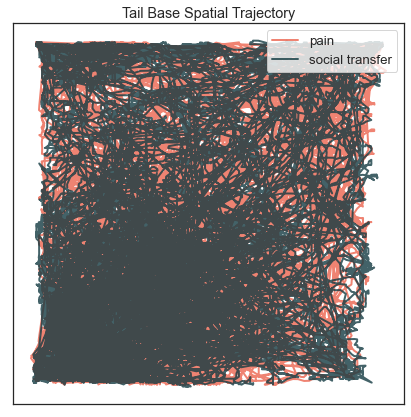

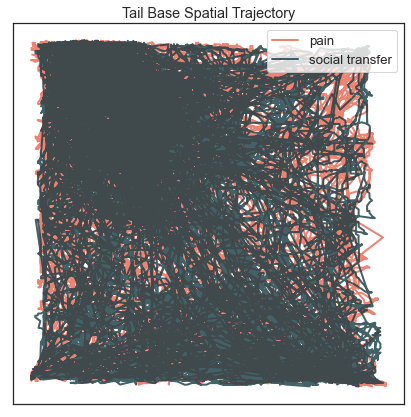

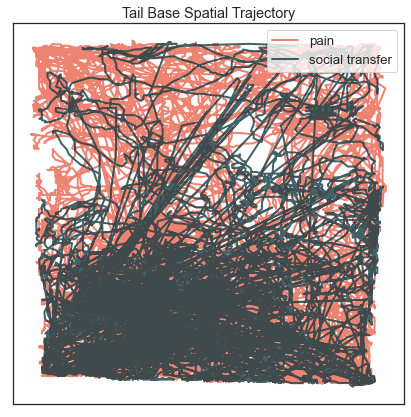

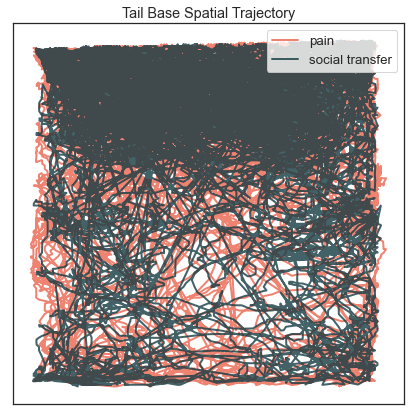

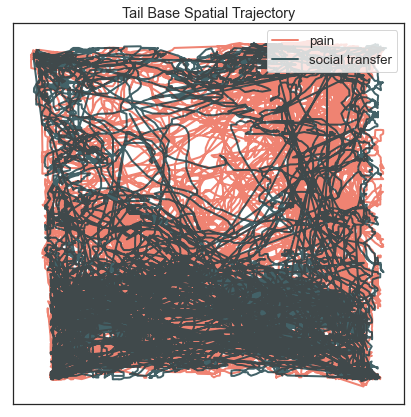

In [7]:

for filename in os.listdir(precap_folder):
    file_path = os.path.join(precap_folder, filename)

    # Skip directories
    if os.path.isdir(file_path):
        print(f"Skipping directory: {file_path}")
        continue

    # Check file extension
    if not filename.endswith(".h5"):
        print(f"Skipping non-HDF5 file: {file_path}")
        continue

    # Verify HDF5 file before opening
    try:
        with h5py.File(file_path, "r") as f:
            print(f"Valid HDF5 file: {file_path}")
    except OSError:
        print(f"Corrupted or invalid HDF5 file: {file_path}")
        continue

    curr = Video(file_path)
    print(f'Processing {curr.filename}')
    curr.main()
    visualize_movement(curr)

# TOTAL DISTANCE TRAVELED

In [8]:
def calculate_total_distance(coords):
    diffs = np.diff(coords, axis = 0)
    distances = np.sqrt(diffs[:, 0]**2 + diffs[:, 1]**2)
    total_distance = np.sum(distances)
    return total_distance

def z_score_normalization(data):
    """
    Normalizes a dictionary of distances using Z-Score normalization.
    """
    values = np.array(list(data.values()))
    mean = np.mean(values)
    std = np.std(values)
    return {key: (val - mean) / std for key, val in data.items()}


def total_distance_traveled(vid, plot = True):
    '''
    TAKES IN VIDEO CLASS, SHOULD ALREADY HAVE MAIN() RAN
    '''
    if type(vid) != Video:
        print('takes in Video class')
        return
    if not vid.main_ran:
        print('run main function first')
        return 
    
    
    cap_traveled = {}
    by_traveled = {}

    
    for i in vid.node_names:
        temp_df = loc_to_df(vid, i)
        cap_coords = temp_df[[f'{i}_cap_x', f'{i}_cap_y']].values
        by_coords = temp_df[[f'{i}_by_x', f'{i}_by_y']].values
        
        cap_traveled[i] = calculate_total_distance(cap_coords)
        by_traveled[i] = calculate_total_distance(by_coords)
        
        
    if plot:
        X = cap_traveled.keys()

        X_axis = np.arange(len(X)) 

        plt.bar(X_axis - 0.2, cap_traveled.values(), 0.4, label = 'CAP MICE', color = cap_c)
        plt.bar(X_axis + 0.2, by_traveled.values(), 0.4, label = 'BY MICE', color = by_c)
    #     plt.hlines(y= video1_avg_across_nodes, xmin = -1, xmax = 8, color='b', linestyle='-', label = f'{video1_label} Average across all nodes')
    #     plt.hlines(y= video2_avg_across_nodes, xmin = -1, xmax = 8, color='orange', linestyle='-', label = f'{video2_label} Average across all nodes')

        #     plt.hlines(y=0.5, xmin=0, xmax=1, color='g', linestyle=':')


        plt.xticks(X_axis, X) 
        plt.xlabel("Nodes") 
        plt.ylabel("Distance Traveled") 
        plt.title("Distance Traveled, By Node") 
        plt.legend() 
        plt.show() 
    
    return cap_traveled, by_traveled

In [9]:
def average_total_distance(folder_path):
    cap_distances = []
    by_distances = []

    # Iterate through files in the folder
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
       # Skip directories
        if os.path.isdir(file_path):
            print(f"Skipping directory: {file_path}")
            continue

        # Check file extension
        if not filename.endswith(".h5"):
            print(f"Skipping non-HDF5 file: {file_path}")
            continue

        # Verify HDF5 file before opening
        try:
            with h5py.File(file_path, "r") as f:
                print(f"Valid HDF5 file: {file_path}")
        except OSError:
            print(f"Corrupted or invalid HDF5 file: {file_path}")
            continue

            
        curr_vid = Video(file_path)
        curr_vid.main()
        
        # Get distances traveled
        cap_traveled, by_traveled = total_distance_traveled(curr_vid, plot=False)
        
        # Append to lists
        cap_distances.append(cap_traveled)
        by_distances.append(by_traveled)

    # Convert lists of dictionaries to DataFrames
    cap_df = pd.DataFrame(cap_distances)
    by_df = pd.DataFrame(by_distances)

    # Compute the mean for each node and combine into a single DataFrame
    avg_df = pd.concat([cap_df.mean().to_frame(name="cap"), 
                        by_df.mean().to_frame(name="by")], axis=1)

    return avg_df

In [11]:
postcap_avg_dist_traveled = average_total_distance(postcap_folder)
postcap_cap_avg =  postcap_avg_dist_traveled.mean()['cap']
postcap_by_avg = postcap_avg_dist_traveled.mean()['by']


#precap_avg_dist_traveled = average_total_distance(precap_folder)
#precap_cap_avg =  precap_avg_dist_traveled.mean()['cap']
#precap_by_avg = precap_avg_dist_traveled.mean()['by']


Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_postCAP_bottom_780_781.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_postCAP_bottom_782_783.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_postCAP_bottom_794_795.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_preCAP_bottom_782_783.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_preCAP_bottom_784_785.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu\lab\FoodDeprivation\2024-06_CAPSLEAPTrain_JieAmanda\SLEAP\male\postcap_h5_ver2\20240623_preCAP_bottom_786_787.analysis.h5
Valid HDF5 file: \\smith-nas.ucsd.edu

In [14]:
print(postcap_avg_dist_traveled)

                       cap             by
nose         232608.210915  220984.760638
R_frontpaw   211799.275863  204715.832703
L_frontpaw   216113.673504  205188.831207
R_hindpaw    213243.805363  183596.188971
L_hindpaw    233644.734567  217034.101279
tail_base    109380.830763   94575.376216
tail_end     140634.439937  111661.678885
body_center  164478.233449  151985.868115


Text(0.5, 1.0, 'Food Deprived Group - Average Total Distance Traveled')

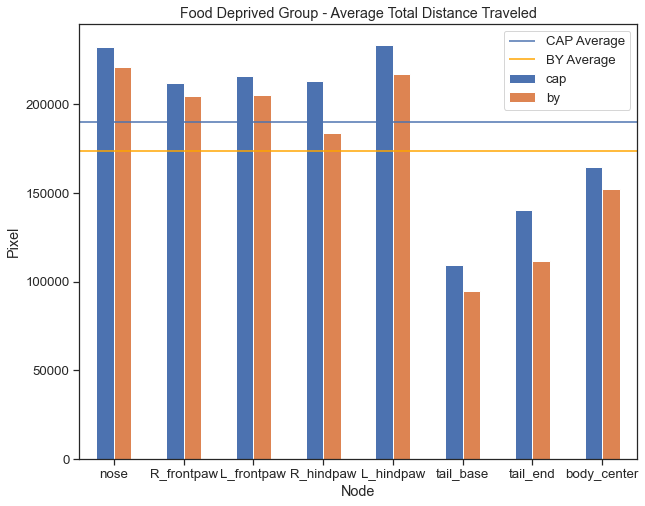

In [12]:
postcap_avg_dist_traveled.plot.bar(y=['cap', 'by'], figsize=(10,8))
plt.xticks(rotation = 0)

plt.hlines(y= postcap_cap_avg, xmin = -1, xmax = 8, color='b', linestyle='-', label = f'CAP Average')
plt.hlines(y= postcap_by_avg, xmin = -1, xmax = 8, color='orange', linestyle='-', label = f'BY Average')

# plt.hlines(y= fed_cap_avg, xmin = -1, xmax = 8, color='r', linestyle='-', label = f'FED CAP Average')
# plt.hlines(y= fed_by_avg, xmin = -1, xmax = 8, color='g', linestyle='-', label = f'FED BY Average')


plt.legend()
plt.xlabel('Node')
plt.ylabel('Pixel')

plt.title("Food Deprived Group - Average Total Distance Traveled")

Text(0.5, 1.0, 'Food Deprived Group - Average Total Distance Traveled')

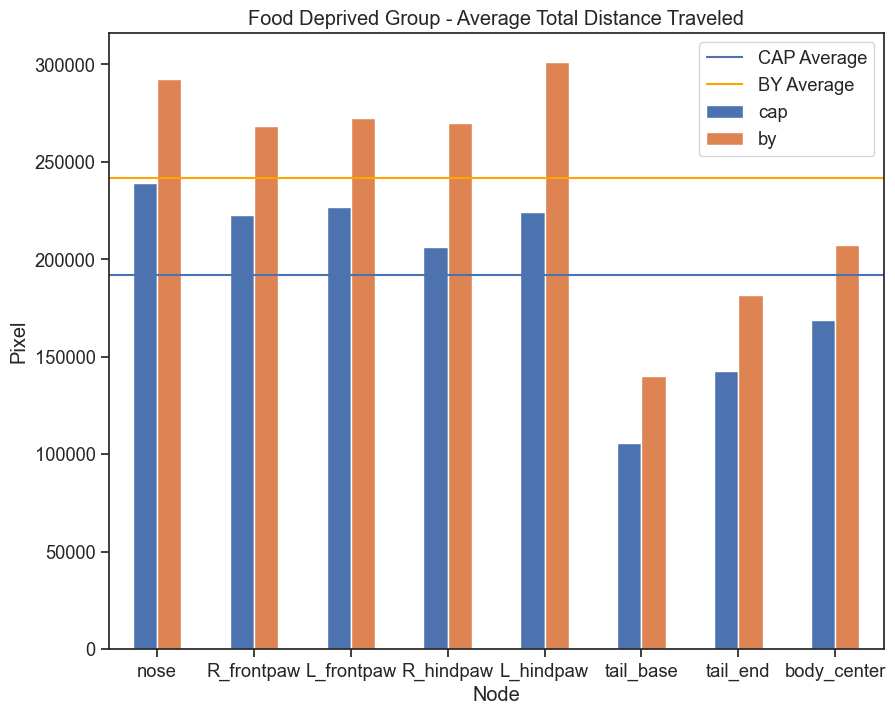

In [79]:
precap_avg_dist_traveled.plot.bar(y=['cap', 'by'], figsize=(10,8))
plt.xticks(rotation = 0)

plt.hlines(y= precap_cap_avg, xmin = -1, xmax = 8, color='b', linestyle='-', label = f'CAP Average')
plt.hlines(y= precap_by_avg, xmin = -1, xmax = 8, color='orange', linestyle='-', label = f'BY Average')
           
           
# plt.hlines(y= fed_cap_avg, xmin = -1, xmax = 8, color='r', linestyle='-', label = f'FED CAP Average')
# plt.hlines(y= fed_by_avg, xmin = -1, xmax = 8, color='g', linestyle='-', label = f'FED BY Average')


plt.legend()
plt.xlabel('Node')
plt.ylabel('Pixel')

plt.title("Food Deprived Group - Average Total Distance Traveled")